In [1]:
import pandas as pd

fake = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\fake-news-project\\data\\Fake.csv")
real = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\fake-news-project\\data\\True.csv")

fake["label"] = 0
real["label"] = 1

data = pd.concat([fake, real])

data.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [2]:
data.shape
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [3]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

data["text"] = data["text"].apply(clean_text)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data["text"])
y = data["label"]

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [6]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9903118040089087
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4588
           1       0.99      0.99      0.99      4392

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



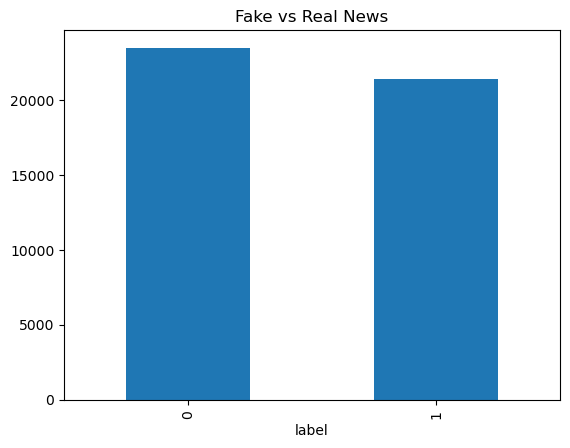

In [7]:
import matplotlib.pyplot as plt

data["label"].value_counts().plot(kind="bar")
plt.title("Fake vs Real News")
plt.show()

In [8]:
import pickle

with open("../models/fake_news_model.pkl", "wb") as f:
    pickle.dump(model, f)

In [9]:
import pickle

# Load saved model
with open("../models/fake_news_model.pkl", "rb") as f:
    model = pickle.load(f)

# Example news
news = ["Breaking: Government announces new policy today"]

# IMPORTANT: use same vectorizer
news_vector = vectorizer.transform(news)

prediction = model.predict(news_vector)

print("Prediction:", prediction)

Prediction: [0]


In [11]:
with open("../models/vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

print("Vectorizer saved ✅")

Vectorizer saved ✅


In [12]:
# Load both
with open("../models/fake_news_model.pkl", "rb") as f:
    model = pickle.load(f)

with open("../models/vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)